In [1]:
import numpy as np
import matplotlib.pyplot as plt

#sample data
np.random.seed(0)
x = np.linspace(-5, 5, 50) # 50 points between -5 and 5
y = 2 * x**2 + 3 * x + np.random.randn(50) * 10 # y = 2x^2 + 3x + some noise

part a:

linear least squares
mean squared error: 372.0052
r-squared: 0.0556

polynomial (cubic)
mean squared error: 107.1117
r-squared: 0.7281

polynomial is the best fit


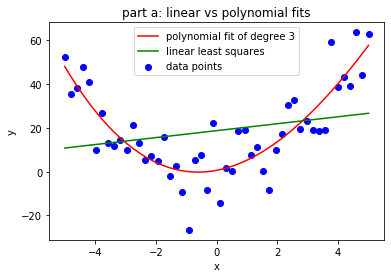

In [2]:
#part A


#least squares 
A = np.vstack([x, np.ones(len(x))]).T
m, c = np.linalg.lstsq(A, y, rcond=None)[0]

y_linear = m*x + c

#polynomial fitting using NumPy's polyfit
degree = 3 
coefficients = np.polyfit(x, y, degree)
polynomial = np.poly1d(coefficients)

# generate predicted y-values based on the fitted polynomial
predicted_y_poly = polynomial(x)

#evaluating the fit of linear and polynomial

#polynomial
mse_poly = np.mean((y - predicted_y_poly)**2)
ss_total = np.sum((y - np.mean(y))**2)
ss_res_poly = np.sum((y - predicted_y_poly)**2)
r_squared_poly = 1 - (ss_res_poly / ss_total)

#linear least squares
mse_linear =  np.mean((y - y_linear)**2)
ss_res_linear = np.sum((y - y_linear)**2)
r_squared_linear = 1 - (ss_res_linear / ss_total)
                     
print("part a:")

print("\nlinear least squares")                      
print(f'mean squared error: {mse_linear:.4f}')
print(f'r-squared: {r_squared_linear:.4f}')

print("\npolynomial (cubic)")                      
print(f'mean squared error: {mse_poly:.4f}')
print(f'r-squared: {r_squared_poly:.4f}')

if mse_linear < mse_poly:
    print("\nlinear least squares is the best fit")
else:
    print("\npolynomial is the best fit")

#plotting
plt.figure()
plt.scatter(x, y, color='blue', label='data points') # Original data points
plt.plot(x, predicted_y_poly, color='red', label=f'polynomial fit of degree {degree}')
plt.plot(x, y_linear, color='green', label='linear least squares')
plt.title('part a: linear vs polynomial fits')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


part b: fit at degree 1
mean squared error: 249.2528
r-squared: 0.2045


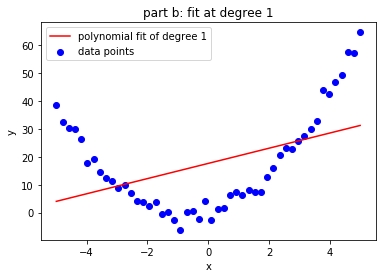

part b: fit at degree 2
mean squared error: 4.3554
r-squared: 0.9861


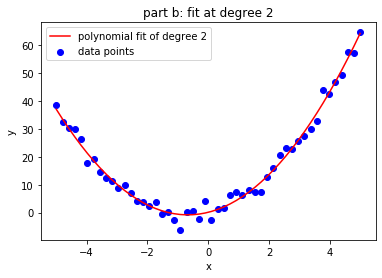

part b: fit at degree 3
mean squared error: 4.2845
r-squared: 0.9863


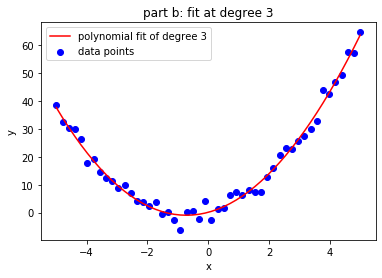

part b: fit at degree 4
mean squared error: 4.2658
r-squared: 0.9864


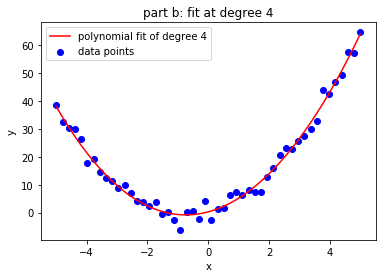

part b: fit at degree 5
mean squared error: 4.2625
r-squared: 0.9864


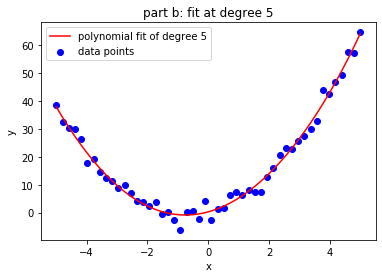

part b: fit at degree 6
mean squared error: 4.2603
r-squared: 0.9864


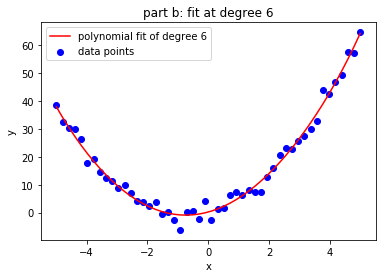

part b: fit at degree 7
mean squared error: 4.2393
r-squared: 0.9865


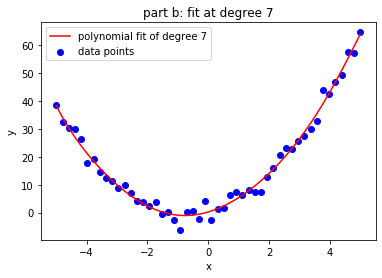

part b: fit at degree 8
mean squared error: 4.2272
r-squared: 0.9865


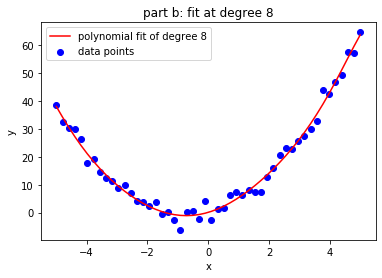

part b: fit at degree 9
mean squared error: 4.1418
r-squared: 0.9868


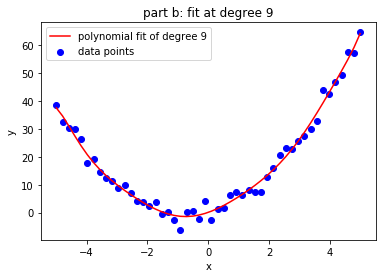

part b: fit at degree 10
mean squared error: 4.1389
r-squared: 0.9868


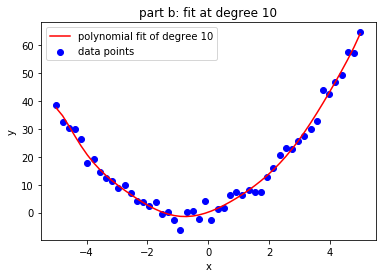

part b: fit at degree 11
mean squared error: 4.0911
r-squared: 0.9869


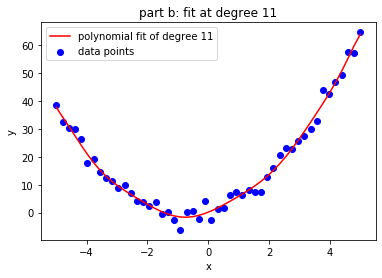

part b: fit at degree 12
mean squared error: 3.6384
r-squared: 0.9884


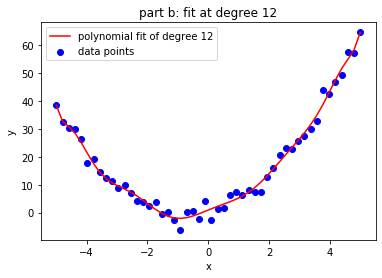

part b: fit at degree 13
mean squared error: 3.6357
r-squared: 0.9884


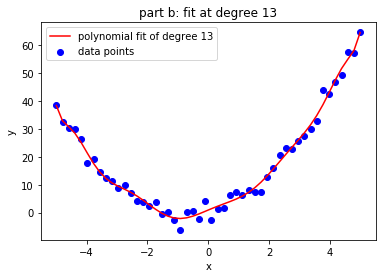

part b: fit at degree 14
mean squared error: 3.6270
r-squared: 0.9884


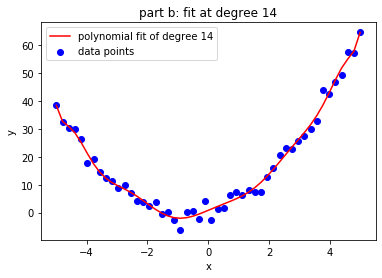

part b: fit at degree 15
mean squared error: 3.4468
r-squared: 0.9890


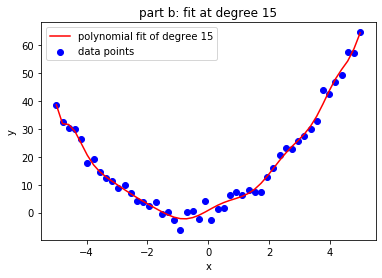

In [3]:
#part b
np.random.seed(0)
x = np.linspace(-5, 5, 50) # 50 points between -5 and 5
y = 2 * x**2 + 3 * x + np.random.randn(50) * 2 # y = 2x^2 + 3x + some noise

ss_total = np.sum((y - np.mean(y))**2)

#polynomial fitting using NumPy's polyfit
for degree in range(1,16):
    coefficients = np.polyfit(x, y, degree)
    polynomial = np.poly1d(coefficients)

    # generate predicted y-values based on the fitted polynomial
    predicted_y_poly = polynomial(x)

    #polynomial
    mse_poly = np.mean((y - predicted_y_poly)**2)
    ss_total = np.sum((y - np.mean(y))**2)
    ss_res_poly = np.sum((y - predicted_y_poly)**2)
    r_squared_poly = 1 - (ss_res_poly / ss_total)

    print(f"part b: fit at degree {degree}")
    print(f'mean squared error: {mse_poly:.4f}')
    print(f'r-squared: {r_squared_poly:.4f}')


    #plotting
    plt.figure()
    plt.scatter(x, y, color='blue', label='data points') # Original data points
    plt.plot(x, predicted_y_poly, color='red', label=f'polynomial fit of degree {degree}')

    plt.title(f'part b: fit at degree {degree}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()


part c: vandermonde polynomial fit
mean squared error: 106.5081
r-squared: 0.7296


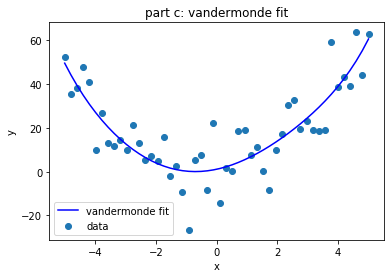

In [4]:
#part c 

np.random.seed(0)
x = np.linspace(-5, 5, 50) # 50 points between -5 and 5
y = 2 * x**2 + 3 * x + np.random.randn(50) * 10 # y = 2x^2 + 3x + some noise

degree = 6

# Vandermonde matrix
V = np.vander(x, N=degree+1, increasing=True)

# Normal equation
VT_V = np.dot(V.T, V)
VT_y = np.dot(V.T, y)

# Solve coefficients
coefficients = np.linalg.solve(VT_V, VT_y)

# predictions
predicted_y_v = V @ coefficients
mse_v = np.mean((y - predicted_y_v)**2)
ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - predicted_y_v)**2)

r_squared_v = 1 - (ss_res / ss_total)


print("part c: vandermonde polynomial fit")
print(f"mean squared error: {mse_v:.4f}")
print(f"r-squared: {r_squared_v:.4f}")


# plot
plt.figure()
plt.scatter(x, y, label="data")
plt.plot(x, predicted_y_v, label="vandermonde fit", color="blue")

plt.title("part c: vandermonde fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()